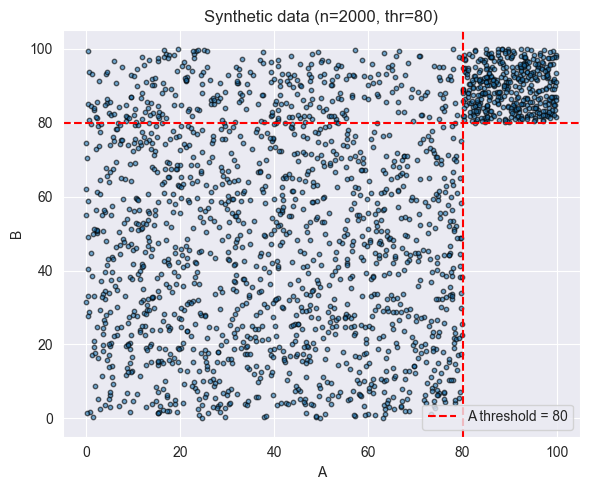

[Timing] p-sweep completed in 2.946 s


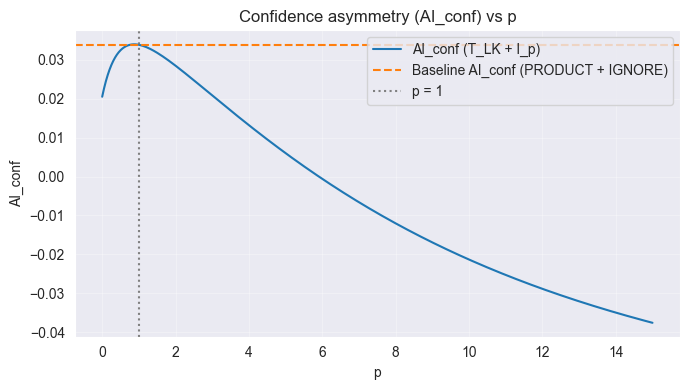

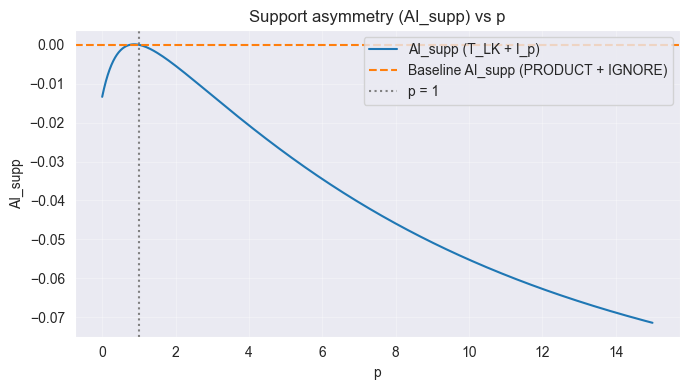

Baseline (PRODUCT + IGNORE): {'supp_r1': 0.2354, 'supp_r2': 0.2354, 'conf_r1': 0.6266, 'conf_r2': 0.5855, 'delta_supp': 0.0, 'delta_conf': 0.0411, 'AI_supp': 0.0, 'AI_conf': 0.0339}
Best p by AI_conf: {'p': 0.8529371237458194, 'AI_conf': 0.033996677191152486}
Best p by AI_supp: {'p': 0.8529371237458194, 'AI_supp': 0.00011799892383953455}


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

import FIRM.base.ct_fuzzy_rule as fuzzy_rule
import FIRM.base.operators.implications as implications
import FIRM.base.operators.tnorms as tnorms
import FIRM.base.fuzzy_data as fuzzy_data

# -----------------------------
# User parameters to change
# -----------------------------
THR = 80           # <-- change threshold here (was 70)
N = 2000           # <-- change number of points here (was 1000)
SEED = 42
NUM_P = 300        # number of points in the p sweep
# -----------------------------

np.random.seed(SEED)
EPS = 1e-12

# -----------------------------
# Synthetic data generator (threshold mechanism)
# -----------------------------
def generate_data(n=1000, thr=70, noise_eta=0.0, seed=42):
    rng = np.random.default_rng(seed)
    A = rng.uniform(0, 100, n)
    B = np.empty(n)
    for i, a in enumerate(A):
        if rng.random() < noise_eta:
            B[i] = rng.uniform(0, 100)  # violation
        else:
            if a > thr:
                B[i] = rng.uniform(thr, 100)
            else:
                B[i] = rng.uniform(0, 100)
    return pd.DataFrame({"A": A, "B": B})

# -----------------------------
# Directionality metrics
# -----------------------------
def directional_metrics(supp_r1, supp_r2, conf_r1, conf_r2):
    return {
        "delta_supp": supp_r1 - supp_r2,
        "delta_conf": conf_r1 - conf_r2,
        "AI_supp": (supp_r1 - supp_r2) / (supp_r1 + supp_r2 + EPS),
        "AI_conf": (conf_r1 - conf_r2) / (conf_r1 + conf_r2 + EPS),
    }

# -----------------------------
# Rule evaluation helper (recreate rules each call)
# -----------------------------
def eval_two_rules(T, I, dataset, fuzzy_dataset):
    rule_AH_to_BH = fuzzy_rule.CRFuzzyRule([(0, 2), (1, 2)])  # A High -> B High
    rule_BH_to_AH = fuzzy_rule.CRFuzzyRule([(1, 2), (0, 2)])  # B High -> A High

    rule_AH_to_BH.evaluate_rule_database(dataset, fuzzy_dataset, T, I)
    rule_BH_to_AH.evaluate_rule_database(dataset, fuzzy_dataset, T, I)

    supp_r1 = float(rule_AH_to_BH.fsupport())
    supp_r2 = float(rule_BH_to_AH.fsupport())
    conf_r1 = float(rule_AH_to_BH.fconfidence())
    conf_r2 = float(rule_BH_to_AH.fconfidence())

    out = {"supp_r1": supp_r1, "supp_r2": supp_r2, "conf_r1": conf_r1, "conf_r2": conf_r2}
    out.update(directional_metrics(supp_r1, supp_r2, conf_r1, conf_r2))
    return out

# -----------------------------
# Operators
# -----------------------------
T_LK = lambda x, y: np.maximum(x + y - 1, 0)
def I_p_factory(p):
    return lambda x, y: 1 - x + x * (y ** p)

I_base = implications.ImplicationsExamples.get_fuzzy_implication(implications.ImplicationsExamples.IGNORE)
T_base = tnorms.TnormsExamples.get_tnorm(tnorms.TnormsExamples.PRODUCT)

# -----------------------------
# Prepare data (with chosen THR and N)
# -----------------------------
df = generate_data(n=N, thr=THR, noise_eta=0.0, seed=SEED)
dataset = df[["A", "B"]]

# Quick scatter to visualize threshold
plt.figure(figsize=(6,5))
plt.scatter(df["A"], df["B"], alpha=0.6, s=10, edgecolor="k")
plt.axvline(THR, color="red", linestyle="--", label=f"A threshold = {THR}")
plt.axhline(THR, color="red", linestyle="--")
plt.xlabel("A")
plt.ylabel("B")
plt.title(f"Synthetic data (n={N}, thr={THR})")
plt.legend()
plt.tight_layout()
plt.show()

# Fuzzify
fuzzy_dataset = fuzzy_data.FuzzyDataQuantiles("symmetric", dataset, 3, ["L", "M", "H"])

# -----------------------------
# p-sweep for I_p and baseline (product+ignore)
# -----------------------------
p_values = np.linspace(0.0001, 15, NUM_P)
traj = []

t0 = time.perf_counter()
for p in p_values:
    I_p = I_p_factory(p)
    out = eval_two_rules(T_LK, I_p, dataset, fuzzy_dataset)
    out["p"] = p
    traj.append(out)
t1 = time.perf_counter()
print(f"[Timing] p-sweep completed in {t1 - t0:.3f} s")

df_traj = pd.DataFrame(traj)

# Baseline evaluated once (doesn't depend on p)
base_out = eval_two_rules(T_base, I_base, dataset, fuzzy_dataset)

# -----------------------------
# Plot: AI_conf vs p with baseline
# -----------------------------
plt.figure(figsize=(7,4))
plt.plot(df_traj["p"], df_traj["AI_conf"], label="AI_conf (T_LK + I_p)", color="C0")
plt.axhline(base_out["AI_conf"], color="C1", linestyle="--", label="Baseline AI_conf (PRODUCT + IGNORE)")
plt.axvline(1, color="gray", linestyle=":", label="p = 1")
plt.xlabel("p")
plt.ylabel("AI_conf")
plt.title("Confidence asymmetry (AI_conf) vs p")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot: AI_supp vs p with baseline
# -----------------------------
plt.figure(figsize=(7,4))
plt.plot(df_traj["p"], df_traj["AI_supp"], label="AI_supp (T_LK + I_p)", color="C0")
plt.axhline(base_out["AI_supp"], color="C1", linestyle="--", label="Baseline AI_supp (PRODUCT + IGNORE)")
plt.axvline(1, color="gray", linestyle=":", label="p = 1")
plt.xlabel("p")
plt.ylabel("AI_supp")
plt.title("Support asymmetry (AI_supp) vs p")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# Print small summary (best p by AI_conf and AI_supp)
# -----------------------------
idx_max_conf = df_traj["AI_conf"].idxmax()
idx_max_supp = df_traj["AI_supp"].idxmax()
print("Baseline (PRODUCT + IGNORE):", {k: round(v,4) for k,v in base_out.items()})
print("Best p by AI_conf:", df_traj.loc[idx_max_conf, ["p","AI_conf"]].to_dict())
print("Best p by AI_supp:", df_traj.loc[idx_max_supp, ["p","AI_supp"]].to_dict())